# Breast Cancer Detection using K-Nearest_Neighbors

## Step 0 : Import necessary libraries

In [1]:
# Import libraries
from sklearn.datasets import load_breast_cancer # import iris dataset from sklearn.datasets
from sklearn.model_selection import train_test_split # import train_test_split from sklearn.model_selection to split the dataset intro traininf and test set

from sklearn.neighbors import KNeighborsClassifier #import k Nearest Neighbor classifier form sklearn.neighbors
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix # from sklearn.metrics, we import accuracy-score and confusion_matrix
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt #library to plot results 
import seaborn as sns #import seaborn for statistical graphics 
import pandas as pd
import numpy as np 
 

##  Step 1 :  Import & Split Breast Cancer Dataset

In [2]:
# load Breast Cancer Dataset as a Data Frame 
Breast_cancer = load_breast_cancer(as_frame = True)
data_df = Breast_cancer.frame

#  print the dataframe
data_df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [3]:
column_names = data_df.columns.values.tolist()
feature_names = column_names[:-1]
feature_names

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

In [4]:
data_df[feature_names]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
#Separate features and target variable
X = data_df.drop(columns='target') #Remove target and keep all the rest of the column
y = data_df['target']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 2 : Initialize the Classification Models

In [6]:
# Initialize model
knn = KNeighborsClassifier()

## Step 3 : Train the models

In [7]:
# here we train each model using X train and the traget y train because we are in supervised learning
knn.fit(X_train, y_train)

KNeighborsClassifier()

## Step 4 : Understand the KNN Model

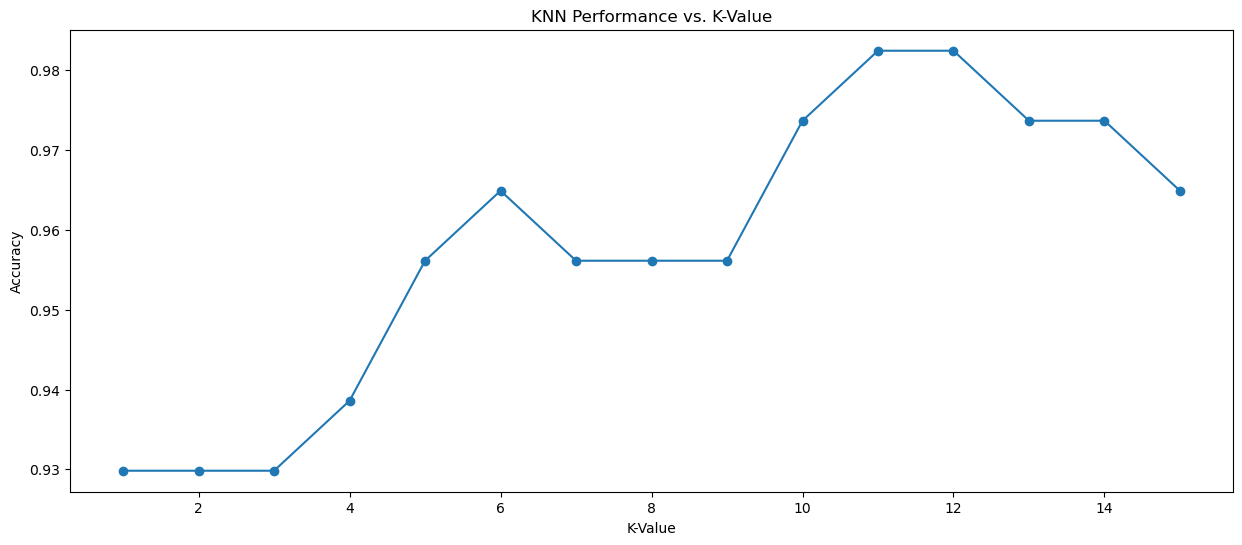

In [8]:
# Define range of K values to test
k_values = np.arange(1, 16)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

# Plot the accuracy
plt.figure(figsize=(15, 6))
plt.plot(k_values, scores, marker='o')
plt.title('KNN Performance vs. K-Value')
plt.xlabel('K-Value')
plt.ylabel('Accuracy')
plt.show()

C:\Users\phili\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


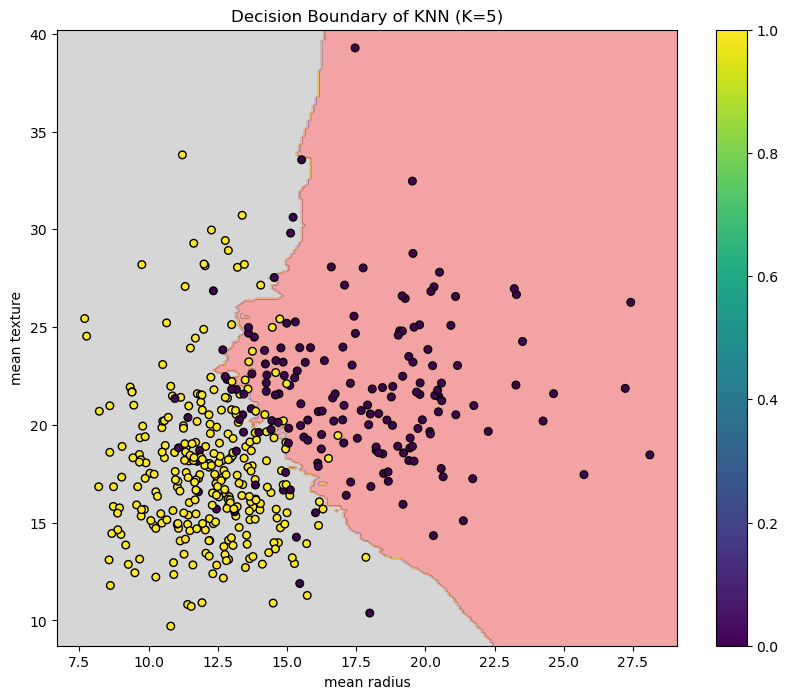

In [9]:
# Assume X_train has only two features for this plot
X_train_2d = X_train.iloc[:, :2]

# Train the KNN classifier on 2D data
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_2d, y_train)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict class probabilities for each point in the mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Set1)

plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, s=30, edgecolor='k') # add cmap=plt.cm.Set1 to see another palette
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('Decision Boundary of KNN (K=5)')
plt.colorbar()
plt.show()

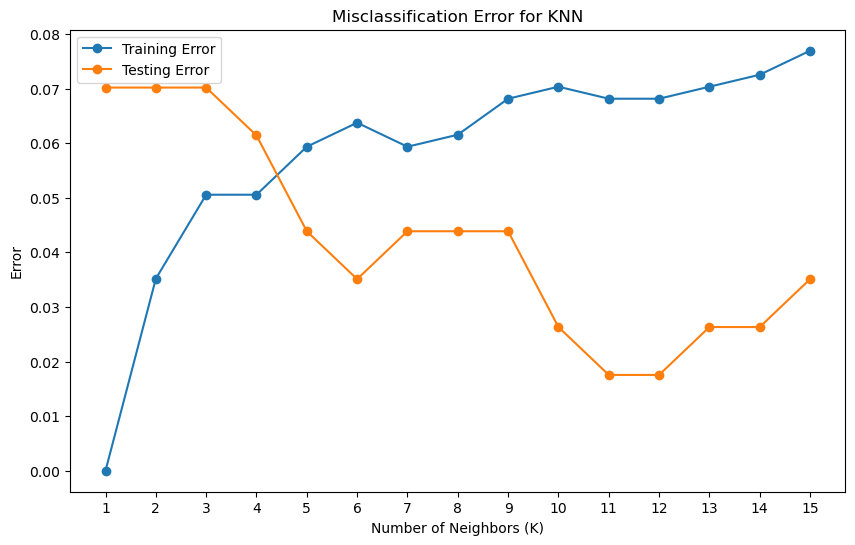

In [10]:
# Define range of K values to test
param_range = np.arange(1, 16)

# Calculate error on training and test set using cross-validation
train_errors, test_errors = [], []
for k in param_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_errors.append(1 - knn.score(X_train, y_train))
    test_errors.append(1 - knn.score(X_test, y_test))

# Plot misclassification error
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_errors, label='Training Error', marker='o')
plt.plot(param_range, test_errors, label='Testing Error', marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Error')
plt.title('Misclassification Error for KNN')
plt.xticks(param_range)
plt.legend()
plt.show()


## Step 5 : Make Predictions

In [11]:
y_pred_knn = knn.predict(X_test)

## Step 6 : Evaluate Models

In [12]:
# Function to calculate results and return as a dictionary
def calculate_results(y_test, y_pred, model_name):
    correct_predictions = np.sum(y_test == y_pred)
    incorrect_predictions = len(y_test) - correct_predictions
    percentage_correct = (correct_predictions / len(y_test)) * 100
    percentage_incorrect = (incorrect_predictions / len(y_test)) * 100
    
    results = {
        'Model': model_name,
        'Correct Predictions': correct_predictions,
        'Incorrect Predictions': incorrect_predictions,
        'Percentage Correct': percentage_correct,
        'Percentage Incorrect': percentage_incorrect
    }
    
    return results

# Collect results for each model
results_list = []
results_list.append(calculate_results(y_test, y_pred_knn, knn))

# Convert list of dictionaries to DataFrame
results_df = pd.DataFrame(results_list)

# Display the DataFrame
results_df

,Model,Correct Predictions,Incorrect Predictions,Percentage Correct,Percentage Incorrect
0,KNeighborsClassifier(n_neighbors=np.int64(15)),110,4,96.491228,3.508772


In [13]:
#Hyperparameter tuning for KNN:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_neighbors': randint(3, 20),             # k from 3 to 19
    'weights': ['uniform', 'distance'],       # weighting scheme
    'p': [1, 2],                              # Manhattan or Euclidean
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}
random_search_knn = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=20,      # try 20 random combinations
    cv=5,           # 5-fold cross-validation
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [15]:
random_search_knn.fit(X_train, y_train)

# Print the best hyperparameters
print("Best parameters from RandomizedSearchCV for KNN:\n", random_search_knn.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV for KNN:
 {'algorithm': 'brute', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}


In [16]:
best_knn = random_search_knn.best_estimator_

In [17]:
y_pred = best_knn.predict(X_test)

In [19]:
from sklearn.metrics import classification_report
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9473684210526315

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint
import random
import numpy as np

# Define parameter distribution for KNN
param_dist = {
    'n_neighbors': randint(3, 20),                # k values
    'weights': ['uniform', 'distance'],           # weighting methods
    'p': [1, 2],                                   # Manhattan or Euclidean
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Create list of randomly sampled parameter sets
n_iter = 20
random_param_sets = []

for _ in range(n_iter):
    params = {
        'n_neighbors': param_dist['n_neighbors'].rvs(),
        'weights': random.choice(param_dist['weights']),
        'p': random.choice(param_dist['p']),
        'algorithm': random.choice(param_dist['algorithm'])
    }
    random_param_sets.append(params)

# Evaluate each param set manually and print live results
results = []

print("🔄 Starting manual random search for KNN...\n")
for i, params in enumerate(random_param_sets, 1):
    knn = KNeighborsClassifier(**params)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    results.append((params, mean_score))
    print(f"Iteration {i}/{n_iter} - Score: {mean_score:.4f} - Params: {params}")

# Find the best parameters from manual search
best_params, best_score = max(results, key=lambda x: x[1])
print("\n🏆 Best Parameters Found:")
print(best_params)
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

# Train final model using best parameters
best_knn = KNeighborsClassifier(**best_params)
best_knn.fit(X_train, y_train)

# Predict on test set
y_pred = best_knn.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("\n📊 Test Set Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


🔄 Starting manual random search for KNN...

Iteration 1/20 - Score: 0.9165 - Params: {'n_neighbors': 14, 'weights': 'uniform', 'p': 2, 'algorithm': 'ball_tree'}
Iteration 2/20 - Score: 0.9165 - Params: {'n_neighbors': 18, 'weights': 'distance', 'p': 2, 'algorithm': 'kd_tree'}
Iteration 3/20 - Score: 0.9319 - Params: {'n_neighbors': 11, 'weights': 'distance', 'p': 1, 'algorithm': 'brute'}
Iteration 4/20 - Score: 0.9165 - Params: {'n_neighbors': 14, 'weights': 'distance', 'p': 2, 'algorithm': 'kd_tree'}
Iteration 5/20 - Score: 0.9363 - Params: {'n_neighbors': 7, 'weights': 'uniform', 'p': 1, 'algorithm': 'kd_tree'}
Iteration 6/20 - Score: 0.9319 - Params: {'n_neighbors': 5, 'weights': 'distance', 'p': 1, 'algorithm': 'ball_tree'}
Iteration 7/20 - Score: 0.9165 - Params: {'n_neighbors': 12, 'weights': 'distance', 'p': 2, 'algorithm': 'brute'}
Iteration 8/20 - Score: 0.9165 - Params: {'n_neighbors': 18, 'weights': 'distance', 'p': 2, 'algorithm': 'ball_tree'}
Iteration 9/20 - Score: 0.9385